# Import Libraries and Load Dataset

### Objective
This step imports the required Python libraries and loads the cleaned credit risk dataset into a Pandas DataFrame for customer segmentation analysis.

### Libraries Used
- **Pandas (`pandas`)** – Data loading and manipulation.
- **NumPy (`numpy`)** – Numerical computations.
- **Matplotlib (`matplotlib.pyplot`)** – Data visualization.
- **Seaborn (`seaborn`)** – Statistical data visualization.

### Dataset
The cleaned dataset is loaded from:

`../dataset/cleaned_credit_risk_data.csv`

Finally, the `head()` function is used to display the first five records to verify that the dataset has been loaded successfully.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../dataset/cleaned_credit_risk_data.csv')
df.head()

,ID,limit_balance,gender,education,marital_status,age,pay_status_1,pay_status_2,pay_status_3,pay_status_4,...,pay_amt_4,pay_amt_5,pay_amt_6,default_next_month,age_group,total_bill_amount,avg_bill_amt,avg_pay_amt,pay_to_bill_ratio,delayed_months_count
0,1,20000,Female,University,Married,24,2,2,-1,-1,...,0,0,0,1,Young Adult (21-30),7704,1284.000000,114.833333,0.089364,2
1,2,120000,Female,University,Single,26,-1,2,0,0,...,1000,0,2000,1,Young Adult (21-30),17077,2846.166667,833.333333,0.292689,2
2,3,90000,Female,University,Single,34,0,0,0,0,...,1000,1000,5000,0,Middle-Aged (31-45),101653,16942.166667,1836.333333,0.108382,0
3,4,50000,Female,University,Married,37,0,0,0,0,...,1100,1069,1000,0,Middle-Aged (31-45),231334,38555.666667,1398.000000,0.036258,0
4,5,50000,Male,University,Married,57,-1,0,-1,0,...,9000,689,679,0,Senior-Aged (46-60),109339,18223.166667,9841.500000,0.540025,0


# Customer Risk Score Calculation

### Objective
This step calculates customer risk scores based on payment behaviour and repayment capacity.

### Process

- A copy of the original dataset is created to preserve the original data.
- **Delinquency Score** is calculated using the `delayed_months_count` column.
  - Customers with more delayed months receive higher risk scores.
- **Capacity Score** is calculated using the `pay_to_bill_ratio` column.
  - Customers with a higher payment-to-bill ratio receive lower risk scores, indicating better repayment capacity.
- The **Total Risk Score** is obtained by adding the delinquency score and capacity score.
- Finally, the first five records are displayed to verify the calculated scores.

In [12]:
segment_df = df.copy()


segment_df['delinquency_score'] = pd.qcut(segment_df['delayed_months_count'].rank(method='first'), 4, labels=[1, 2, 3, 4])
segment_df['delinquency_score'] = segment_df['delinquency_score'].astype(int)

segment_df['capacity_score'] = pd.qcut(segment_df['pay_to_bill_ratio'].rank(method='first'), 4, labels=[4, 3, 2, 1])
segment_df['capacity_score'] = segment_df['capacity_score'].astype(int)

segment_df['total_risk_score'] = segment_df['delinquency_score'] + segment_df['capacity_score']

print(segment_df[['ID', 'delayed_months_count', 'pay_to_bill_ratio', 'delinquency_score', 'capacity_score', 'total_risk_score']].head())

   ID  delayed_months_count  pay_to_bill_ratio  delinquency_score  \
0   1                     2           0.089364                  4   
1   2                     2           0.292689                  4   
2   3                     0           0.108382                  1   
3   4                     0           0.036258                  1   
4   5                     0           0.540025                  1   

   capacity_score  total_risk_score  
0               2                 6  
1               2                 6  
2               2                 3  
3               4                 5  
4               2                 3  


# Customer Risk Segmentation

### Objective
This step classifies customers into different risk segments based on their total risk score.

### Process

- A custom function named `assign_risk_segment()` is created to categorize customers according to their total risk score.
- Customers are assigned to one of the following risk segments:
  - **Healthy** – Low-risk customers with good repayment behaviour.
  - **Watchlist** – Customers who require regular monitoring.
  - **At-Risk** – Customers with a higher probability of repayment issues.
  - **Critical** – High-risk customers requiring immediate attention.
- The `apply()` function is used to assign a risk segment to each customer.
- Finally, the number of customers in each segment is displayed using `value_counts()`.

In [13]:
def assign_risk_segment(score):
    if score <= 3:
        return 'Healthy'
    elif score <= 5:
        return 'Watchlist'
    elif score <= 7:
        return 'At-Risk'
    else:
        return 'Critical'

segment_df['risk_segment'] = segment_df['total_risk_score'].apply(assign_risk_segment)

segment_counts = segment_df['risk_segment'].value_counts()
print(segment_counts)

risk_segment
Watchlist    12187
At-Risk       9137
Healthy       6241
Critical      2435
Name: count, dtype: int64


# Risk Segment Validation

### Objective
This step evaluates whether the customer risk segments accurately reflect the likelihood of loan default.

### Process

- Customers are grouped according to their assigned risk segment.
- For each segment, the following statistics are calculated:
  - **Count** – Total number of customers in the segment.
  - **Mean Default Rate** – Average default value for customers in the segment.
- The default rate is converted into a percentage for easier interpretation.
- Finally, the validation results are displayed to compare default rates across all risk segments.

In [14]:

segment_validation = segment_df.groupby('risk_segment')['default_next_month'].agg(['count', 'mean'])
segment_validation['default_rate_percentage'] = segment_validation['mean'] * 100
print(segment_validation[['count', 'default_rate_percentage']])

              count  default_rate_percentage
risk_segment                                
At-Risk        9137                31.947029
Critical       2435                53.511294
Healthy        6241                12.562089
Watchlist     12187                13.374908


# Customer Segmentation Visualization

### Objective
This step visualizes the distribution of customers across different risk segments and compares the default rate for each segment.

### Process

- Customer statistics are summarized for each risk segment.
- The total number of customers in each segment is calculated.
- The default rate percentage is calculated for every segment.
- Two bar charts are created:
  - **Customer Count by Risk Segment** – Displays the number of customers in each segment.
  - **Default Rate across Risk Segments** – Compares the percentage of customers who defaulted in each segment.
- Different colors are used to improve readability and distinguish the risk categories.

C:\Users\UsEr\AppData\Local\Temp\ipykernel_11116\1370005084.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\UsEr\AppData\Local\Temp\ipykernel_11116\1370005084.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


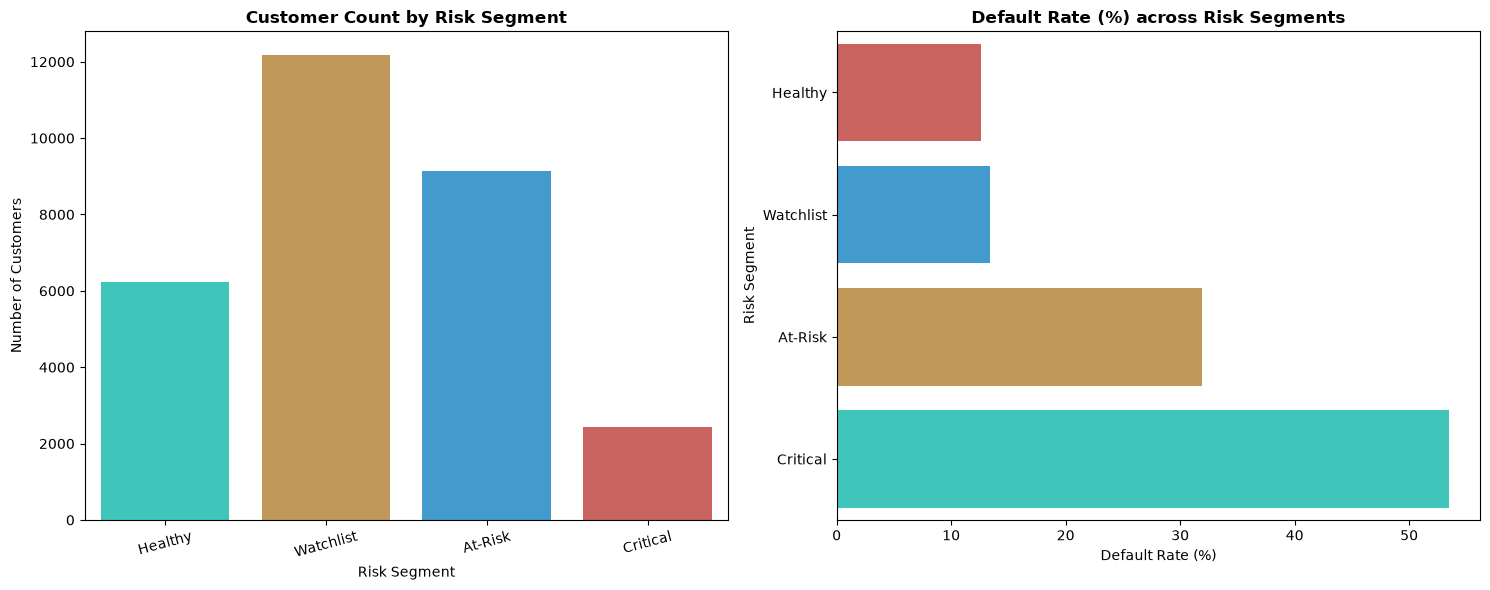

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

segment_order = ['Healthy', 'Watchlist', 'At-Risk', 'Critical']

segment_summary = segment_df.groupby('risk_segment').agg(
    customer_count=('ID', 'count'),
    default_rate=('default_next_month', lambda x: x.mean() * 100)
).reindex(segment_order).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

custom_colors = ["#29dbcc", "#d19d49", "#2ba0e4", '#d9534f']

sns.barplot(
    ax=axes[0], 
    x='risk_segment', 
    y='customer_count', 
    data=segment_summary, 
    order=segment_order, 
    palette=custom_colors
)
axes[0].set_title('Customer Count by Risk Segment', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Risk Segment', fontsize=10)
axes[0].set_ylabel('Number of Customers', fontsize=10)
axes[0].tick_params(axis='x', rotation=15) 

sns.barplot(
    ax=axes[1], 
    x='default_rate', 
    y='risk_segment', 
    data=segment_summary, 
    order=segment_order, 
    palette=custom_colors[::-1] 
)
axes[1].set_title('Default Rate (%) across Risk Segments', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Default Rate (%)', fontsize=10)
axes[1].set_ylabel('Risk Segment', fontsize=10)

plt.tight_layout()
plt.show()